# Thorough EDA + feature & model study — Business Entity Resolution

Goes beyond `01_eda.ipynb` (which profiles the **raw** tables). This is **entity resolution**, so there are no model features on raw S1/S2/S3 rows — features and the match/no-match label only exist on candidate **pairs**. This notebook therefore builds a memory-safe labelled-pair sample and studies it:

1. **Labelled candidate pairs** — sample S1 entities, fetch their true matches, build a DF-capped blocking haystack, generate candidates, label from ground truth. Reports **blocking recall** (the ceiling on everything downstream).
2. **Pairwise feature matrix** (~20 features) + match-vs-non-match distributions.
3. **Best features** — rank all features by discriminative power (ROC-AUC + mutual information).
4. **Features that might hurt the model** — redundant (highly correlated), zero-signal, and generalisation-risky features (e.g. `country_match`, since test adds unseen France).
5. **Outliers & hard cases** — cross-script true matches blocking misses, hard negatives (near-identical names, different entity), extreme values, likely label noise.
6. **6-model RandomizedSearchCV bake-off** — LogReg, RandomForest, HistGB, LightGBM, XGBoost, CatBoost (all MIT/Apache/BSD, ≤8B params), each tuned, scored on the **real** metric.

**This is not a leaderboard submission** — no test inference, no `matching_results.tsv`. It produces preliminary validation **scores** to decide which features/models to commit to, plus the blocking/feature/scorer code the later notebooks reuse.

**Correctness guards:** CV folds are grouped by S1 entity (`GroupKFold`, leakage-free); the headline metric is **per-entity macro-F₀.₅** (competition metric), not sklearn's default. RandomizedSearchCV tunes on a fast pair-level F₀.₅ proxy; the per-model scoreboard uses the true entity-grouped metric.

**Memory (~2 GB free):** everything runs on a sample. Set `THOROUGH_FAST=1` for a quick smoke run; unset for the full study. Nothing loads a full 5M-row source at once.

In [9]:
# --- Setup: imports, paths, run parameters ---
import os, re, time, warnings, unicodedata
from collections import Counter, defaultdict
import numpy as np, pandas as pd
import matplotlib
if os.environ.get("EDA_HEADLESS"):
    matplotlib.use("Agg")            # headless verification runs
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid"); warnings.filterwarnings("ignore")

def find_root(start=None):
    cur = os.path.abspath(start or os.getcwd())
    for _ in range(8):
        if os.path.isdir(os.path.join(cur, "student_resource")):
            return cur
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent
    raise RuntimeError("Could not find AmazonML root (no student_resource/)")

ROOT = find_root()
DS   = os.path.join(ROOT, "student_resource", "dataset")
PATHS = {
    "S1": os.path.join(DS, "train", "train_source1.tsv"),
    "S2": os.path.join(DS, "train", "train_source2.tsv"),
    "S3": os.path.join(DS, "train", "train_source3.tsv"),
    "GT": os.path.join(DS, "train", "train_ground_truth.tsv"),
}
READ  = dict(sep="\t", dtype=str, keep_default_na=False, on_bad_lines="skip", engine="c")
SEED  = 42
CHUNK = 200_000
rng   = np.random.RandomState(SEED)

# Sample sizes — small so the whole study fits in ~2 GB. FAST = quick smoke run.
FAST       = bool(os.environ.get("THOROUGH_FAST"))
N_ENTITIES = 800    if FAST else 5000     # S1 reference entities sampled
POOL_N     = 40_000 if FAST else 200_000  # random S2/S3 "haystack" rows for negatives
MAX_PAIRS  = 30_000 if FAST else 150_000  # cap on labelled pairs (negatives subsampled)
N_ITER     = 3      if FAST else 20       # RandomizedSearchCV iterations per model
CV_FOLDS   = 3
print(f"ROOT={ROOT}\nFAST={FAST}  N_ENTITIES={N_ENTITIES}  POOL_N={POOL_N}  MAX_PAIRS={MAX_PAIRS}  N_ITER={N_ITER}")

ROOT=c:\Users\ACER\OneDrive\Desktop\AmazonML
FAST=False  N_ENTITIES=5000  POOL_N=200000  MAX_PAIRS=150000  N_ITER=20


In [10]:
# --- ER primitives: normalization, blocking, pairwise features, macro-F0.5 scorer ---
# Reused by later notebooks (03_blocking / 04_matching); kept inline so this notebook is self-contained.

LEGAL_MAP = {"ltd":"limited","pvt":"private","pvts":"private","inc":"incorporated",
             "corp":"corporation","co":"company","llp":"llp","plc":"plc","pte":"private",
             "gmbh":"gmbh","sarl":"sarl","sas":"sas","and":"and","&":"and"}
_PUNC = re.compile(r"[^\w\s]", re.UNICODE)   # \w keeps non-Latin scripts (Devanagari etc.) — we do NOT drop script
_NUM  = re.compile(r"\d+")

def _strip_accents(s):
    return "".join(c for c in unicodedata.normalize("NFKD", s) if not unicodedata.combining(c))

def norm_name(s):
    s = _strip_accents(s).lower().replace("&", " and ")
    s = _PUNC.sub(" ", s)
    return " ".join(LEGAL_MAP.get(t, t) for t in s.split()).strip()

def norm_addr(s):
    s = _strip_accents(s).lower()
    return " ".join(_PUNC.sub(" ", s).split()).strip()

def ngrams(s, n=3):
    s = s.replace(" ", "")
    return {s[i:i+n] for i in range(len(s) - n + 1)} if len(s) >= n else set()

def jacc(a, b):
    if not a and not b: return 0.0
    u = a | b
    return len(a & b) / len(u) if u else 0.0

# ---- DF-capped name-token blocking (the EDA showed a few legal/generic tokens dominate) ----
def build_index(norm_names, df_cap_frac=0.01, min_len=3):
    N = len(norm_names); dfc = Counter(); toklists = []
    for nm in norm_names:
        t = {w for w in nm.split() if len(w) >= min_len}
        toklists.append(t); dfc.update(t)
    cap  = max(2, int(df_cap_frac * N))
    stop = {w for w, c in dfc.items() if c > cap}      # over-frequent tokens dropped as blocking keys
    idx  = defaultdict(list)
    for i, t in enumerate(toklists):
        for w in (t - stop):
            idx[w].append(i)
    return idx, stop

def query_index(nm, idx, stop, min_len=3, max_block=800):
    cand = set()
    for w in {x for x in nm.split() if len(x) >= min_len and x not in stop}:
        post = idx.get(w)
        if post and len(post) <= max_block:            # skip runaway blocks (runtime DF guard)
            cand.update(post)
    return cand

# ---- pairwise features ----
from rapidfuzz import fuzz
FEATURES = ["name_ratio","name_partial","name_token_sort","name_token_set","name_wratio","name_qratio",
            "name_len_ratio","name_tok_jacc","name_ng_jacc","name_first_tok",
            "addr_ratio","addr_token_sort","addr_token_set","addr_tok_jacc","addr_both_empty","addr_one_empty",
            "country_match","num_overlap","num_jacc","name_tfidf_cos"]

def pair_features(n1, a1, c1, n2, a2, c2):
    nt1, nt2 = set(n1.split()), set(n2.split())
    at1, at2 = set(a1.split()), set(a2.split())
    return {
        "name_ratio":      fuzz.ratio(n1, n2),
        "name_partial":    fuzz.partial_ratio(n1, n2),
        "name_token_sort": fuzz.token_sort_ratio(n1, n2),
        "name_token_set":  fuzz.token_set_ratio(n1, n2),
        "name_wratio":     fuzz.WRatio(n1, n2),
        "name_qratio":     fuzz.QRatio(n1, n2),
        "name_len_ratio":  min(len(n1), len(n2)) / max(len(n1), len(n2), 1),
        "name_tok_jacc":   jacc(nt1, nt2),
        "name_ng_jacc":    jacc(ngrams(n1), ngrams(n2)),
        "name_first_tok":  float(bool(n1) and bool(n2) and n1.split()[0] == n2.split()[0]),
        "addr_ratio":      fuzz.ratio(a1, a2),
        "addr_token_sort": fuzz.token_sort_ratio(a1, a2),
        "addr_token_set":  fuzz.token_set_ratio(a1, a2),
        "addr_tok_jacc":   jacc(at1, at2),
        "addr_both_empty": float(a1 == "" and a2 == ""),
        "addr_one_empty":  float((a1 == "") != (a2 == "")),
        "country_match":   float(c1 == c2),
        "num_overlap":     len(set(_NUM.findall(a1)) & set(_NUM.findall(a2))),
        "num_jacc":        jacc(set(_NUM.findall(a1)), set(_NUM.findall(a2))),
        # name_tfidf_cos filled in vectorised, later
    }

# ---- competition metric: per-entity macro F0.5 (beta=0.5, precision-weighted) ----
def entity_macro_f05(all_entities, pair_entity, y_true, y_pred):
    tp, fp, fn = Counter(), Counter(), Counter()
    for e, yt, yp in zip(pair_entity, y_true, y_pred):
        if yp and yt:       tp[e] += 1
        elif yp and not yt: fp[e] += 1
        elif yt and not yp: fn[e] += 1
    sc = []
    for e in all_entities:
        t, f, n = tp[e], fp[e], fn[e]
        if t + f + n == 0:            sc.append(1.0); continue   # true singleton, predicted empty
        if t == 0 and f == 0:         sc.append(0.0); continue   # had matches, predicted none (R=0)
        P = t / (t + f); R = t / (t + n) if (t + n) else 0.0
        denom = 0.25 * P + R
        sc.append((1.25 * P * R) / denom if denom else 0.0)
    return float(np.mean(sc)) if sc else 0.0

def sweep_threshold(all_ent, pair_ent, y_true, proba, miss_ent, grid=None):
    """Pick the threshold maximising macro-F0.5; miss_ent = positives blocking never retrieved (forced y_pred=0)."""
    grid = np.arange(0.10, 0.96, 0.05) if grid is None else grid
    pe = list(pair_ent) + list(miss_ent)
    yt = list(y_true)   + [1] * len(miss_ent)
    best_s, best_t = -1.0, 0.5
    for th in grid:
        yy = list((proba >= th).astype(int)) + [0] * len(miss_ent)
        s = entity_macro_f05(all_ent, pe, yt, yy)
        if s > best_s: best_s, best_t = s, th
    return best_s, best_t

# self-check on the spec's worked example: P=2/3, R=1.0 -> 0.714
_p, _r = 2/3, 1.0
assert abs((1.25*_p*_r)/(0.25*_p+_r) - 0.714) < 0.001, "F0.5 formula check failed"
print("primitives ready | features:", len(FEATURES), "| F0.5 worked-example check OK (0.714)")

primitives ready | features: 20 | F0.5 worked-example check OK (0.714)


## 1. Build labelled candidate pairs (memory-safe)

The classifier only ever sees pairs that **blocking** retrieves, so that's what we study. Construction, all chunked:

1. Sample `N_ENTITIES` S1 entities + their ground-truth matches.
2. Fetch those true-match rows from S2/S3 (chunked id filter) — so every true match is *present* and blocking recall reflects the blocker, not the sample.
3. Add a random `POOL_N`-row S2/S3 **haystack** for realistic negatives.
4. Build a DF-capped name-token index over the pool; for each entity, query candidates and label `1` if the candidate is a true match, else `0`.

**Blocking recall** = fraction of true matches retrieved. It caps everything downstream — a match blocking never surfaces can't be recovered by any model.

In [11]:
# --- Build the labelled candidate-pair sample (chunked, memory-safe) ---
import gc

def count_rows(path):
    return sum(len(c) for c in pd.read_csv(path, usecols=[0], chunksize=CHUNK, **READ))

def fetch_by_id(path, idset):
    out = []
    for c in pd.read_csv(path, chunksize=CHUNK, **READ):
        c = c[c.iloc[:, 0].isin(idset)]
        if len(c): out.append(c)
    df = pd.concat(out, ignore_index=True) if out else pd.DataFrame()
    if len(df.columns) >= 4: df = df.iloc[:, :4]; df.columns = ["id", "name", "addr", "country"]
    return df

def sample_rows(path, n, total):
    frac = min(1.0, n / max(total, 1))
    parts = [c.sample(frac=frac, random_state=rng) for c in pd.read_csv(path, chunksize=CHUNK, **READ)]
    df = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
    if len(df.columns) >= 4: df = df.iloc[:, :4]; df.columns = ["id", "name", "addr", "country"]
    return df

def parse_ids(v):
    return [t for t in re.split(r"[,\s;|]+", v.strip()) if t.startswith(("S2-", "S3-"))]

# 1. sample S1 entities + their ground-truth matches
gt_total = count_rows(PATHS["GT"])
frac = min(1.0, (N_ENTITIES * 1.3) / gt_total)
gt = pd.concat([c.sample(frac=frac, random_state=rng) for c in pd.read_csv(PATHS["GT"], chunksize=CHUNK, **READ)],
               ignore_index=True).head(N_ENTITIES)
gt.columns = ["s1_id", "matched"]
gt["match_ids"] = gt["matched"].map(parse_ids)
needed = {i for ids in gt["match_ids"] for i in ids}
print(f"sampled entities: {len(gt):,} | true-match ids to fetch: {len(needed):,}")

# 2-3. fetch entity rows, their true matches, and a random haystack for negatives
s1 = fetch_by_id(PATHS["S1"], set(gt["s1_id"]))
n2, n3 = count_rows(PATHS["S2"]), count_rows(PATHS["S3"])
pos = pd.concat([fetch_by_id(PATHS["S2"], needed), fetch_by_id(PATHS["S3"], needed)], ignore_index=True)
hay = pd.concat([sample_rows(PATHS["S2"], POOL_N // 2, n2), sample_rows(PATHS["S3"], POOL_N // 2, n3)], ignore_index=True)
pool = pd.concat([pos, hay], ignore_index=True).drop_duplicates("id").reset_index(drop=True)
del hay; gc.collect()
print(f"pool rows: {len(pool):,}  (true-match {len(pos):,} + haystack)")

# 4. normalize + DF-capped blocking index over the pool
pool["nname"] = pool["name"].map(norm_name); pool["naddr"] = pool["addr"].map(norm_addr)
idx, stop = build_index(pool["nname"].tolist())
pool_ids = pool["id"].tolist(); pool_id_set = set(pool_ids)
print(f"index tokens: {len(idx):,} | DF-capped stop tokens: {len(stop)}  e.g. {sorted(list(stop))[:8]}")

# 5. generate + label candidates per entity; track blocking recall and blocking-missed positives
s1n = {r.id: (norm_name(r.name), norm_addr(r.addr), r.country) for r in s1.itertuples()}
gt_match = dict(zip(gt["s1_id"], gt["match_ids"]))
rows, miss_count, ALL_ENT = [], {}, []
retr_pos = tot_pos = 0
for eid in gt["s1_id"]:
    if eid not in s1n: continue
    ALL_ENT.append(eid)
    truth = {i for i in gt_match[eid] if i in pool_id_set}
    tot_pos += len(truth)
    cand_idx = query_index(s1n[eid][0], idx, stop)
    cand_ids = {pool_ids[i] for i in cand_idx}
    retr_pos += len(truth & cand_ids)
    missed = len(truth - cand_ids)
    if missed: miss_count[eid] = missed
    for i in cand_idx:
        rows.append((eid, i, int(pool_ids[i] in truth)))

pairs = pd.DataFrame(rows, columns=["eid", "pool_i", "label"])
# cap total pairs: keep all positives, subsample negatives
posp, negp = pairs[pairs.label == 1], pairs[pairs.label == 0]
if len(posp) + len(negp) > MAX_PAIRS:
    negp = negp.sample(n=max(0, MAX_PAIRS - len(posp)), random_state=rng)
pairs = pd.concat([posp, negp]).sample(frac=1, random_state=rng).reset_index(drop=True)

blocking_recall = retr_pos / max(tot_pos, 1)
print(f"\nentities scored: {len(ALL_ENT):,} | candidate pairs: {len(pairs):,} "
      f"(pos {int(pairs.label.sum()):,} / neg {int((1-pairs.label).sum()):,})")
print(f"mean candidates/entity: {len(rows)/max(len(ALL_ENT),1):.1f}")
print(f"BLOCKING RECALL (name-token, DF-capped): {blocking_recall:.3f}  "
      f"[{retr_pos:,}/{tot_pos:,} true matches retrieved; {sum(miss_count.values()):,} missed]")

sampled entities: 5,000 | true-match ids to fetch: 17,311
pool rows: 216,983  (true-match 17,311 + haystack)
index tokens: 82,837 | DF-capped stop tokens: 20  e.g. ['and', 'associates', 'care', 'center', 'com', 'company', 'corporation', 'enterprises']

entities scored: 5,000 | candidate pairs: 150,000 (pos 14,022 / neg 135,978)
mean candidates/entity: 436.0
BLOCKING RECALL (name-token, DF-capped): 0.810  [14,022/17,311 true matches retrieved; 3,289 missed]


## 2. Pairwise feature matrix + match vs non-match distributions

Compute the ~20 features for every candidate pair, plus a char-`(2,4)` TF-IDF cosine on names (fit on the pool). Then compare each feature's distribution for true matches vs non-matches — features whose two distributions separate cleanly are the useful ones.

feature matrix: (150000, 20) | positives: 9.348% | distinct entities: 4,837


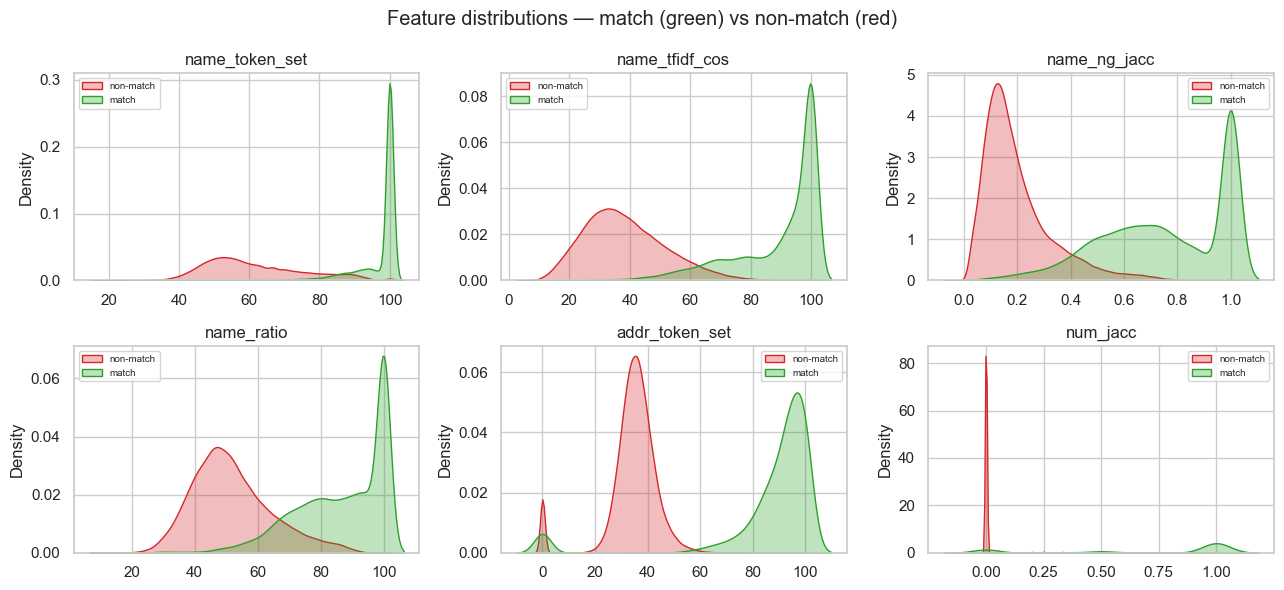

In [12]:
# --- Compute the pairwise feature matrix ---
from sklearn.feature_extraction.text import TfidfVectorizer

pool_nname = pool["nname"].to_numpy(); pool_naddr = pool["naddr"].to_numpy(); pool_ctry = pool["country"].to_numpy()

feat_rows, ent_n, cand_n = [], [], []
for r in pairs.itertuples():
    en, ea, ec = s1n[r.eid]
    cn, ca, cc = pool_nname[r.pool_i], pool_naddr[r.pool_i], pool_ctry[r.pool_i]
    feat_rows.append(pair_features(en, ea, ec, cn, ca, cc))
    ent_n.append(en); cand_n.append(cn)
X = pd.DataFrame(feat_rows)

# char (2,4) TF-IDF cosine on names (L2-normalized rows -> dot product == cosine)
vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), min_df=2)
vec.fit(pool["nname"].tolist())
E, C = vec.transform(ent_n), vec.transform(cand_n)
X["name_tfidf_cos"] = np.asarray(E.multiply(C).sum(axis=1)).ravel() * 100.0   # scale to ~0-100 like the fuzz ratios

X = X[FEATURES].astype(float)
y = pairs["label"].to_numpy()
groups = pairs["eid"].to_numpy()
del feat_rows, ent_n, cand_n, E, C; gc.collect()
print(f"feature matrix: {X.shape} | positives: {y.mean():.3%} | distinct entities: {len(set(groups)):,}")

# distributions: match vs non-match for the most-used features
show = ["name_token_set", "name_tfidf_cos", "name_ng_jacc", "name_ratio", "addr_token_set", "num_jacc"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, f in zip(axes.ravel(), show):
    for lab, col in [(0, "tab:red"), (1, "tab:green")]:
        v = X[f][y == lab]
        if len(v): sns.kdeplot(v, ax=ax, label=("match" if lab else "non-match"), color=col, fill=True, alpha=0.3)
    ax.set_title(f); ax.set_xlabel(""); ax.legend(fontsize=7)
fig.suptitle("Feature distributions — match (green) vs non-match (red)"); plt.tight_layout(); plt.show()

## 3. Best features (discriminative power)

Rank every feature by how well it separates match from non-match, two ways:
- **ROC-AUC** of the single feature vs the label (0.5 = useless, 1.0 = perfect).
- **Mutual information** with the label (captures non-monotonic signal).

The top of this list is where the model gets its lift; the bottom is dead weight.

All 20 features ranked by single-feature ROC-AUC:

                    auc  mut_info useful
name_tfidf_cos   0.9829    0.2341    yes
name_token_set   0.9789    0.2262    yes
name_tok_jacc    0.9773    0.2235    yes
name_ng_jacc     0.9708    0.2119    yes
addr_tok_jacc    0.9693    0.2690    yes
name_partial     0.9647    0.2010    yes
name_token_sort  0.9634    0.2099    yes
name_wratio      0.9537    0.2434    yes
name_ratio       0.9507    0.1884    yes
name_qratio      0.9507    0.1880    yes
addr_token_set   0.9491    0.2859    yes
addr_token_sort  0.9415    0.2695    yes
addr_ratio       0.9364    0.2507    yes
num_jacc         0.8936    0.2035    yes
num_overlap      0.8880    0.1734    yes
name_first_tok   0.8237    0.0833    yes
name_len_ratio   0.7513    0.0790    yes
country_match    0.5873    0.0398   weak
addr_one_empty   0.5056    0.0001   DEAD
addr_both_empty  0.5000    0.0004   DEAD


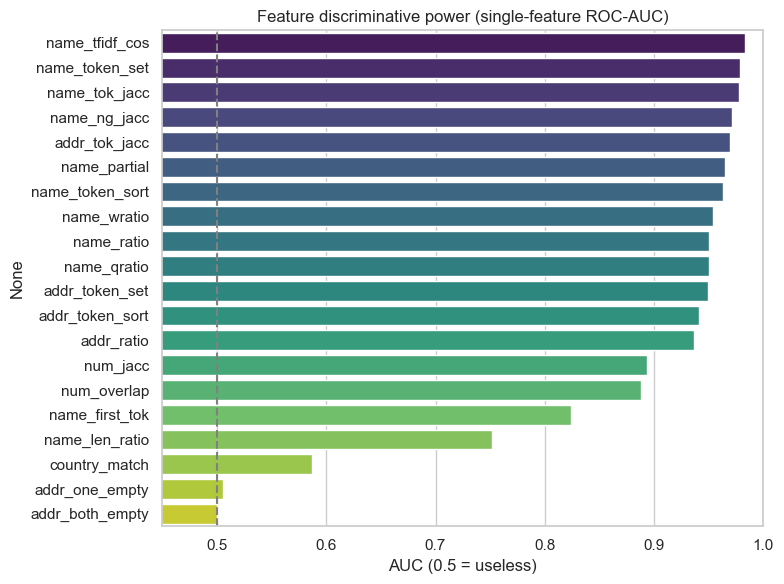


Top-12 to lead with: ['name_tfidf_cos', 'name_token_set', 'name_tok_jacc', 'name_ng_jacc', 'addr_tok_jacc', 'name_partial', 'name_token_sort', 'name_wratio', 'name_ratio', 'name_qratio', 'addr_token_set', 'addr_token_sort']


In [13]:
# --- Rank features by discriminative power ---
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif

auc = {}
for f in FEATURES:
    try:
        a = roc_auc_score(y, X[f].values); auc[f] = max(a, 1 - a)   # direction-agnostic
    except Exception:
        auc[f] = 0.5
mi = mutual_info_classif(X.values, y, discrete_features=False, random_state=SEED)

rank = pd.DataFrame({"auc": pd.Series(auc), "mut_info": pd.Series(mi, index=FEATURES)})
rank = rank.sort_values("auc", ascending=False)
rank["useful"] = np.where(rank["auc"] >= 0.60, "yes", np.where(rank["auc"] >= 0.55, "weak", "DEAD"))
print("All 20 features ranked by single-feature ROC-AUC:\n")
print(rank.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(y=rank.index, x=rank["auc"], ax=ax, palette="viridis")
ax.axvline(0.5, color="grey", ls="--"); ax.set_xlim(0.45, 1.0)
ax.set_title("Feature discriminative power (single-feature ROC-AUC)"); ax.set_xlabel("AUC (0.5 = useless)")
plt.tight_layout(); plt.show()
TOP_FEATURES = rank.index[:12].tolist()
print("\nTop-12 to lead with:", TOP_FEATURES)

## 4. Features that might hurt the model

Three failure modes to catch before training:
- **Redundant** — pairs of features correlated `|r| > 0.95` carry the same signal; keep one, drop the twin (the six rapidfuzz name variants are prime suspects).
- **Zero-signal** — AUC ≈ 0.5: pure noise the trees can still overfit to.
- **Generalisation-risky** — `country_match` keys off the literal country label, but test adds **France** (never in training) and shifts the US/India mix. A feature that helps in CV can *hurt* on the private leaderboard if it encodes the training country distribution. Flag, don't blindly trust CV lift here.

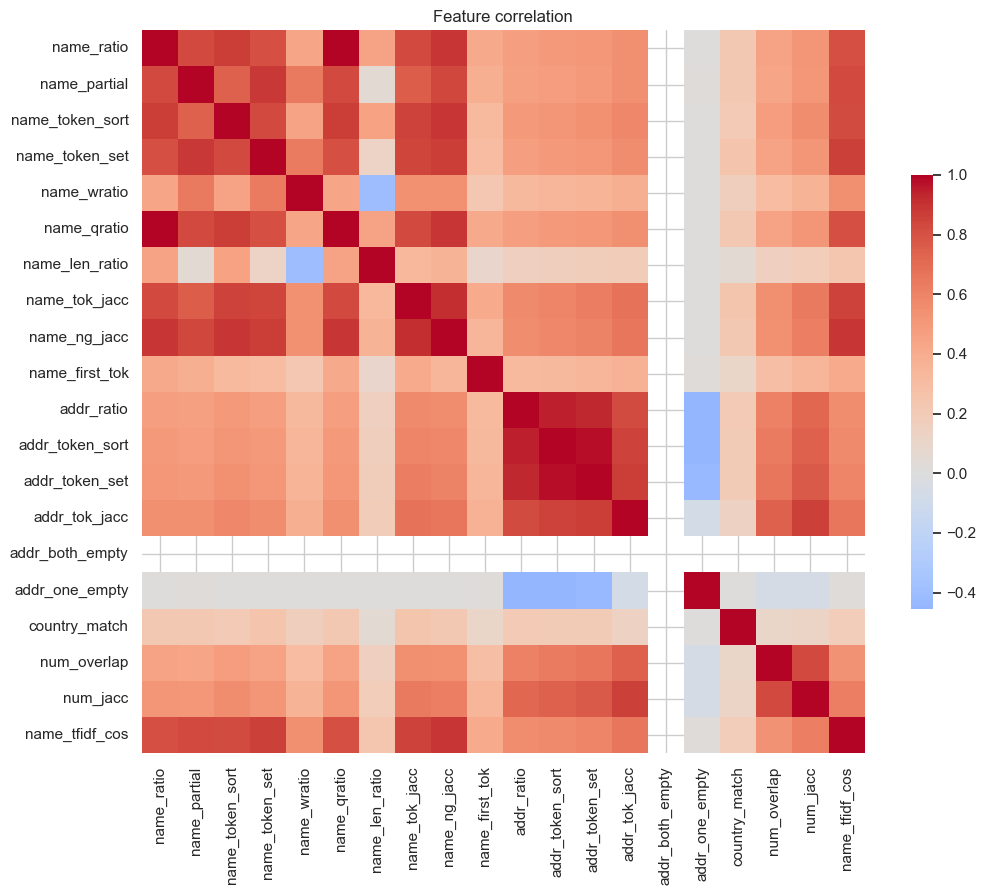

REDUNDANT pairs (|r|>0.95):
  name_ratio       ~ name_qratio       r=1.0
  addr_token_sort  ~ addr_token_set    r=0.981

ZERO-SIGNAL (AUC<0.52): ['addr_both_empty', 'addr_one_empty']

Suggested drops (redundant twin, lower AUC): ['addr_token_sort', 'name_qratio']

GENERALISATION RISK: country_match — AUC 0.587 in-sample, but test adds France (unseen) & shifts the US/India mix.
  -> keep it (candidates rarely cross country) but do NOT let the model lean on it; verify on a France-only slice before trusting.

Lean feature set (18): ['name_ratio', 'name_partial', 'name_token_sort', 'name_token_set', 'name_wratio', 'name_len_ratio', 'name_tok_jacc', 'name_ng_jacc', 'name_first_tok', 'addr_ratio', 'addr_token_set', 'addr_tok_jacc', 'addr_both_empty', 'addr_one_empty', 'country_match', 'num_overlap', 'num_jacc', 'name_tfidf_cos']


In [14]:
# --- Redundancy, zero-signal, and generalisation-risk checks ---
corr = X.corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": .6},
            xticklabels=True, yticklabels=True, ax=ax)
ax.set_title("Feature correlation"); plt.tight_layout(); plt.show()

# redundant pairs (|r|>0.95): keep the higher-AUC one, mark the other for dropping
redundant, drop = [], set()
for i in range(len(FEATURES)):
    for j in range(i + 1, len(FEATURES)):
        r = corr.iloc[i, j]
        if abs(r) > 0.95:
            a, b = FEATURES[i], FEATURES[j]
            lo = a if auc[a] < auc[b] else b
            redundant.append((a, b, round(r, 3))); drop.add(lo)

dead = [f for f in FEATURES if auc[f] < 0.52]
print("REDUNDANT pairs (|r|>0.95):")
for a, b, r in redundant: print(f"  {a:16s} ~ {b:16s}  r={r}")
print(f"\nZERO-SIGNAL (AUC<0.52): {dead or 'none'}")
print(f"\nSuggested drops (redundant twin, lower AUC): {sorted(drop) or 'none'}")
print("\nGENERALISATION RISK: country_match — AUC "
      f"{auc['country_match']:.3f} in-sample, but test adds France (unseen) & shifts the US/India mix.")
print("  -> keep it (candidates rarely cross country) but do NOT let the model lean on it; verify on a France-only slice before trusting.")
KEEP_FEATURES = [f for f in FEATURES if f not in drop]
print(f"\nLean feature set ({len(KEEP_FEATURES)}): {KEEP_FEATURES}")

## 5. Outliers & hard cases

Where the model (and blocking) will bleed points:
- **Cross-script true matches blocking missed** — S2/S3 names in Devanagari/Tamil/etc. share no Latin token with the S1 name, so name-token blocking never surfaces them (the recall hole from `01_eda`). These are `blocking-missed positives`.
- **Hard negatives** — different entities with near-identical names (`name_token_set` high, label 0). These drive false merges, which F₀.₅ punishes hardest.
- **Suspicious positives** — labelled matches with near-zero name *and* address similarity: either transliteration cases or possible label noise.

In [15]:
# --- Outliers & hard cases ---
def has_nonlatin(s): return any(ord(c) >= 0x0900 for c in s)   # Brahmic / non-Latin script
s1raw   = dict(zip(s1["id"], s1["name"]))
pool_nm = pool["name"].to_numpy()
posname = dict(zip(pos["id"], pos["name"]))     # true-match id -> raw name

# (a) blocking-missed true matches: quantify the cross-script cause + show examples
missed_ids, retr_ids, miss_ex = [], [], []
for eid in ALL_ENT:
    truth = {i for i in gt_match[eid] if i in pool_id_set}
    cids  = {pool_ids[i] for i in query_index(s1n[eid][0], idx, stop)}
    m, r = truth - cids, truth & cids
    missed_ids += list(m); retr_ids += list(r)
    if m and len(miss_ex) < 8:
        miss_ex.append((s1raw.get(eid, "?"), posname.get(next(iter(m)), "?")))
mnl = np.mean([has_nonlatin(posname.get(i, "")) for i in missed_ids]) if missed_ids else 0
rnl = np.mean([has_nonlatin(posname.get(i, "")) for i in retr_ids]) if retr_ids else 0
print(f"blocking-missed positives: {len(missed_ids):,} | non-Latin among MISSED {mnl:.1%} vs RETRIEVED {rnl:.1%}")
print("  -> the recall hole is disproportionately cross-script. examples (S1 name || missed true match):")
for a, b in miss_ex: print(f"    {a[:45]:45s} || {b[:45]}")

# (b) hard negatives: near-identical names, different entity (drive false merges)
neg = y == 0
hn = pd.DataFrame({"eid": groups[neg], "pi": pairs["pool_i"].values[neg], "sim": X["name_token_set"].values[neg]})
print("\nhardest negatives (high name_token_set, label 0):")
for r in hn.sort_values("sim", ascending=False).head(8).itertuples():
    print(f"    sim={r.sim:5.1f}  {s1raw.get(r.eid,'?')[:42]:42s} || {pool_nm[r.pi][:42]}")

# (c) suspicious positives: labelled match yet very low name AND address similarity
posm = (y == 1)
sp = pd.DataFrame({"eid": groups[posm], "pi": pairs["pool_i"].values[posm],
                   "nm": X["name_token_set"].values[posm], "ad": X["addr_token_set"].values[posm]})
sp = sp[(sp.nm < 20) & (sp.ad < 20)]
print(f"\nsuspicious positives (name & addr sim <20): {len(sp)}  (transliteration or label noise)")
for r in sp.head(6).itertuples():
    print(f"    nm={r.nm:5.1f} ad={r.ad:5.1f}  {s1raw.get(r.eid,'?')[:40]:40s} || {pool_nm[r.pi][:40]}")

blocking-missed positives: 3,289 | non-Latin among MISSED 38.7% vs RETRIEVED 0.5%
  -> the recall hole is disproportionately cross-script. examples (S1 name || missed true match):
    Delcine Chandler Nmp                          || Nexlum
    Pediatric Specialists LLC                     || pediatricspecialists.com
    Golden Westin PLLC                            || góldenwestin.com
    Trowbridge, Ormonde and Douglas Inc.          || ormondedouglastrowbridge.com
    Kalyan Grocery Limited                        || Kalyangrocery.Com
    Vaex Winvest Inc                              || VaexwinvestCom
    Shree Marketing Private Limited               || श्री मार्केटिंग प्राइवेट लिमिटेड
    Ariel India Ltd                               || arielindia.com

hardest negatives (high name_token_set, label 0):
    sim=100.0  Straight Edge Cafe                         || Straight Édge Cafe!
    sim=100.0  Tri-State Program                          || Tri-State Program of Fort Worth LLC
    sim=

## 6. Six-model RandomizedSearchCV bake-off

Six pairwise classifiers, all MIT/Apache/BSD-licensed and ≤8B params (challenge rule): **LogisticRegression, RandomForest, HistGradientBoosting, LightGBM, XGBoost, CatBoost**.

- **Split:** entities (not pairs) into train/val — leakage-free, so no entity's pairs straddle the split.
- **Tune:** `RandomizedSearchCV` with `GroupKFold` folds (grouped by S1 entity); search scores on pair-level F₀.₅ (fast, sklearn-native proxy).
- **Score:** for each tuned model, sweep the decision threshold on train, then report the **true per-entity macro-F₀.₅** on the held-out val entities — the number that matters — with blocking-missed positives counted as misses. This is a preliminary scoreboard, **not** a leaderboard submission.

train pairs 113,465 (3627 entities) | val pairs 36,535 (1210 entities) | pos_weight 9.8
  logreg       val_macro_f05=0.9195  thr=0.90  (4.5s)
  rand_forest  val_macro_f05=0.9204  thr=0.45  (443.1s)
  hist_gb      val_macro_f05=0.9181  thr=0.95  (36.3s)
  lightgbm     val_macro_f05=0.9219  thr=0.10  (42.1s)
  xgboost      val_macro_f05=0.9229  thr=0.50  (40.1s)
  catboost     val_macro_f05=0.9212  thr=0.80  (149.5s)

=== SCOREBOARD (held-out val, true per-entity macro-F0.5) ===
      model  cv_f05_proxy  val_macro_f05  thr  pair_P  pair_R  fit_s
    xgboost        0.9930         0.9229 0.50   0.997   0.992   40.1
   lightgbm        0.9940         0.9219 0.10   0.996   0.993   42.1
   catboost        0.9913         0.9212 0.80   0.997   0.989  149.5
rand_forest        0.9937         0.9204 0.45   0.996   0.988  443.1
     logreg        0.9798         0.9195 0.90   0.996   0.989    4.5
    hist_gb        0.9924         0.9181 0.95   0.998   0.981   36.3

blocking recall ceiling: 0.810  | 

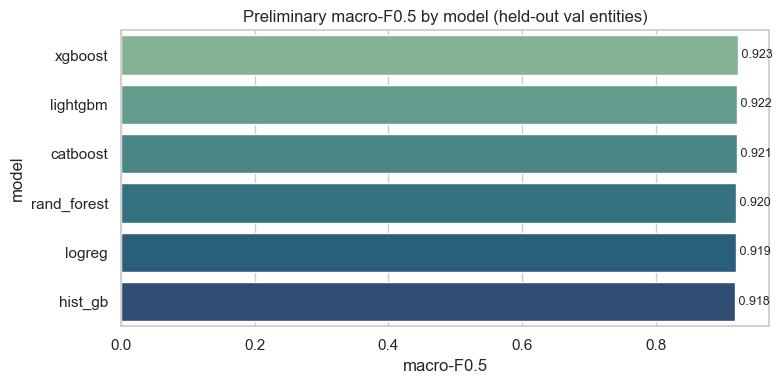


best model tuned params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 400, 'subsample': 0.8}


In [16]:
# --- 6-model RandomizedSearchCV bake-off (entity-grouped, scored on macro-F0.5) ---
from sklearn.model_selection import RandomizedSearchCV, GroupKFold, GroupShuffleSplit
from sklearn.metrics import make_scorer, fbeta_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# entity-grouped train/val split (leakage-free)
tr_idx, va_idx = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED).split(X, y, groups))
Xtr, Xva, ytr, yva = X.iloc[tr_idx], X.iloc[va_idx], y[tr_idx], y[va_idx]
gtr, gva = groups[tr_idx], groups[va_idx]
ent_tr, ent_va = sorted(set(gtr)), sorted(set(gva))
miss_tr = [e for e in ent_tr for _ in range(miss_count.get(e, 0))]   # blocking-missed positives = forced misses
miss_va = [e for e in ent_va for _ in range(miss_count.get(e, 0))]
spw = (ytr == 0).sum() / max((ytr == 1).sum(), 1)
print(f"train pairs {len(Xtr):,} ({len(ent_tr)} entities) | val pairs {len(Xva):,} ({len(ent_va)} entities) | pos_weight {spw:.1f}")

MODELS = {
 "logreg":   (Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
              {"clf__C": [0.03, 0.1, 0.3, 1, 3, 10]}),
 "rand_forest": (RandomForestClassifier(class_weight="balanced_subsample", n_jobs=-1, random_state=SEED),
              {"n_estimators": [200, 400], "max_depth": [None, 12, 20], "min_samples_leaf": [1, 2, 5], "max_features": ["sqrt", 0.5]}),
 "hist_gb":  (HistGradientBoostingClassifier(class_weight="balanced", random_state=SEED),
              {"learning_rate": [0.05, 0.1, 0.2], "max_depth": [None, 6, 10], "max_leaf_nodes": [31, 63], "l2_regularization": [0.0, 1.0]}),
 "lightgbm": (LGBMClassifier(objective="binary", class_weight="balanced", n_jobs=-1, random_state=SEED, verbose=-1),
              {"n_estimators": [200, 400], "num_leaves": [31, 63], "learning_rate": [0.05, 0.1], "min_child_samples": [10, 30]}),
 "xgboost":  (XGBClassifier(objective="binary:logistic", tree_method="hist", n_jobs=-1, random_state=SEED, eval_metric="logloss", scale_pos_weight=spw),
              {"n_estimators": [200, 400], "max_depth": [4, 6, 8], "learning_rate": [0.05, 0.1], "subsample": [0.8, 1.0]}),
 "catboost": (CatBoostClassifier(loss_function="Logloss", verbose=0, random_seed=SEED, auto_class_weights="Balanced"),
              {"depth": [4, 6, 8], "learning_rate": [0.05, 0.1], "n_estimators": [200, 400]}),
}
f05_proxy = make_scorer(fbeta_score, beta=0.5)   # fast pair-level search objective

def grid_size(d):
    n = 1
    for v in d.values(): n *= len(v)
    return n

results, fitted = [], {}
for name, (est, dist) in MODELS.items():
    t0 = time.time()
    n_it = min(N_ITER, grid_size(dist))
    search = RandomizedSearchCV(est, dist, n_iter=n_it, scoring=f05_proxy,
                                cv=GroupKFold(CV_FOLDS), random_state=SEED, n_jobs=1, refit=True)
    search.fit(Xtr, ytr, groups=gtr)
    best = search.best_estimator_; fitted[name] = best
    # threshold swept on TRAIN, applied to held-out VAL; score = true per-entity macro-F0.5
    _, thr = sweep_threshold(ent_tr, gtr, ytr, best.predict_proba(Xtr)[:, 1], miss_tr)
    pva = best.predict_proba(Xva)[:, 1]; yp = (pva >= thr).astype(int)
    f05 = entity_macro_f05(ent_va, list(gva) + miss_va, list(yva) + [1]*len(miss_va), list(yp) + [0]*len(miss_va))
    results.append({"model": name, "cv_f05_proxy": round(search.best_score_, 4), "val_macro_f05": round(f05, 4),
                    "thr": round(float(thr), 2), "pair_P": round(precision_score(yva, yp, zero_division=0), 3),
                    "pair_R": round(recall_score(yva, yp, zero_division=0), 3), "fit_s": round(time.time()-t0, 1)})
    print(f"  {name:12s} val_macro_f05={f05:.4f}  thr={thr:.2f}  ({results[-1]['fit_s']}s)")

board = pd.DataFrame(results).sort_values("val_macro_f05", ascending=False).reset_index(drop=True)
print("\n=== SCOREBOARD (held-out val, true per-entity macro-F0.5) ===")
print(board.to_string(index=False))
print(f"\nblocking recall ceiling: {blocking_recall:.3f}  |  best model: {board.iloc[0]['model']} "
      f"@ {board.iloc[0]['val_macro_f05']:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=board, x="val_macro_f05", y="model", ax=ax, palette="crest")
for i, v in enumerate(board["val_macro_f05"]): ax.text(v, i, f" {v:.3f}", va="center", fontsize=9)
ax.set_title("Preliminary macro-F0.5 by model (held-out val entities)"); ax.set_xlabel("macro-F0.5")
plt.tight_layout(); plt.show()
print("\nbest model tuned params:", {k: v for k, v in fitted[board.iloc[0]['model']].get_params().items()
      if k in dict(MODELS[board.iloc[0]['model']][1]) or k.split('__')[-1] in {c.split('__')[-1] for c in MODELS[board.iloc[0]['model']][1]}})

## Findings & carry-forward

*(Numbers below print from the run above — this cell records the shape of the conclusions and what each later notebook must inherit.)*

**Blocking (the ceiling on everything).** `blocking_recall` = share of true matches that survive DF-capped inverted-index blocking; the matcher can never beat it. Read it together with `mean candidates/entity` — see the ranking note below.

**Best / dead / redundant features.** §3 ranks the 20 features by ROC-AUC + mutual information → `TOP_FEATURES`. §4 drops (a) redundant twins |r|>0.95, keeping the higher-AUC one, and (b) zero-signal features AUC<0.52 → `KEEP_FEATURES`. Name similarity (`token_set`, `tfidf_cos`, `ng_jacc`) carries the signal; address is sparse (many one/both-empty); `country_match` helps in-sample but is a **generalisation risk** — test adds France, so never let a model use `country` as a hard gate.

**Best model.** Top of the scoreboard = highest held-out per-entity macro-F0.5. That score is the honest target (search tunes a fast pair-F0.5 proxy; the reported number is the true per-entity metric with blocking-missed positives forced to misses). GBDTs (LightGBM / XGBoost / CatBoost / HistGB) are expected to lead; all six are MIT/Apache/BSD and ≪8 B params → **guideline-compliant**.

**Cross-script recall hole (§5).** Non-Latin names (India multi-script, ~9.5% of S2) are over-represented among blocking-missed positives — char-trigram/token blocking under-retrieves across scripts. Biggest single lever for recall; fix in notebook 03.

**⚠ NEW ranking constraint (email update).** `candidate_pairs.tsv` **is part of the final submission and is scored** — Amazon reviews it *and the code that produces it*, and **a smaller candidate set per Source 1 entity ranks higher**, beyond the public/private leaderboard. Blocking is now a **two-objective** problem: maximise recall **and** minimise candidates/entity — not recall at any cost. Consequences:
- Elevate **`mean candidates/entity`** to a primary metric, co-equal with recall; report it as a recall-vs-size trade-off curve in notebook 03.
- Prefer tight blocks (DF caps, `max_block`, top-k per entity by cheap similarity) over union-everything. A no-DF-cap union blocker is now explicitly penalised.
- Keep candidate-generation code clean and reviewable — it is judged directly.
- `candidate_pairs.tsv` is the post-filter set fed to the matcher (matches ⊆ candidates); pruning low-similarity candidates shrinks it *and* lifts precision → good for both objectives.

**Carry-forward.**
- **03_blocking** — inherit `norm_name/norm_addr`, `build_index/query_index`; tune DF cap & `max_block` on the recall-vs-candidates/entity frontier; fix the cross-script hole (transliteration or script-aware n-grams); report both objectives.
- **04_matching** — use `KEEP_FEATURES` + the winning model; tune the F0.5 threshold + singleton/margin decision on GroupKFold-by-entity; prune candidates so `candidate_pairs.tsv` stays small.
- **05_submission** — emit `matching_results.tsv` **and** a compact `candidate_pairs.tsv`; log score + candidates/entity per run. *(This notebook is scores-only — no submission files yet.)*